In [12]:
import pandas as pd


In [13]:
df = pd.read_parquet("../data/merged/merged_adm1_wide_normalized.parquet")

In [14]:
df

,Country,location_name_full,Level 1,Area,adm1_pcode,adm2_pcode,From,To,Validity period,Date of analysis,...,acled_total_fatalities_per_100k_population,idp_population_over_adm1_population,gdelt_verbal_coop_events_per_100k_population,gdelt_verbal_coop_mentions_per_100k_population,gdelt_material_coop_events_per_100k_population,gdelt_material_coop_mentions_per_100k_population,gdelt_verbal_conflict_events_per_100k_population,gdelt_verbal_conflict_mentions_per_100k_population,gdelt_material_conflict_events_per_100k_population,gdelt_material_conflict_mentions_per_100k_population
0,AFG,Afghanistan,Kabul,None,AF01,,2017-08-01,2017-11-30 23:59:59,current,2017-08-01T00:00:00,...,0.005187,0.000059,0.617079,3.109015,0.103881,0.567991,0.138074,0.796185,0.232547,1.520615
1,AFG,Afghanistan,Kabul,None,AF01,,2018-08-01,2018-10-31 23:59:59,current,2018-08-01T00:00:00,...,0.00402,0.0,0.425197,2.207448,0.065584,0.369554,0.086634,0.531229,0.169282,1.120687
2,AFG,Afghanistan,Kabul,None,AF01,,2018-11-01,2019-02-28 23:59:59,first projection,2018-11-01T00:00:00,...,0.003786,0.00003,0.756571,3.773848,0.10248,0.560402,0.132736,0.765878,0.180774,1.176981
3,AFG,Afghanistan,Kabul,None,AF01,,2019-08-01,2019-10-31 23:59:59,current,2019-08-01T00:00:00,...,0.005654,0.0,0.534332,2.841374,0.07761,0.44593,0.121411,0.687201,0.174819,1.069014
4,AFG,Afghanistan,Kabul,None,AF01,,2019-11-01,2020-03-31 23:59:59,first projection,2019-11-01T00:00:00,...,0.002769,0.000021,0.710802,3.689816,0.149099,0.809245,0.143662,0.782758,0.178572,1.027982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9514,ZWE,Zimbabwe,Masvingo,None,ZW18,,2019-06-01,2019-09-30 23:59:59,current,2019-06-01T00:00:00,...,<NA>,0.001637,137.280013,684.48477,20.188237,105.651775,36.908239,195.670607,23.760002,129.722365
9515,ZWE,Zimbabwe,Masvingo,None,ZW18,,2019-10-01,2019-12-31 23:59:59,first projection,2019-10-01T00:00:00,...,<NA>,0.000603,95.71295,477.581221,17.548237,96.644715,23.552943,132.621189,19.256472,96.59295
9516,ZWE,Zimbabwe,Masvingo,None,ZW18,,2020-02-01,2020-06-30 23:59:59,current,2020-02-01T00:00:00,...,<NA>,<NA>,152.602367,766.169484,36.131768,196.80943,42.136475,231.232963,34.992944,178.01884
9517,ZWE,Zimbabwe,Masvingo,None,ZW18,,2020-10-01,2020-12-31 23:59:59,current,2020-10-01T00:00:00,...,<NA>,0.0001,75.214125,382.489448,12.423531,69.77883,14.494119,76.04236,10.560001,51.09177


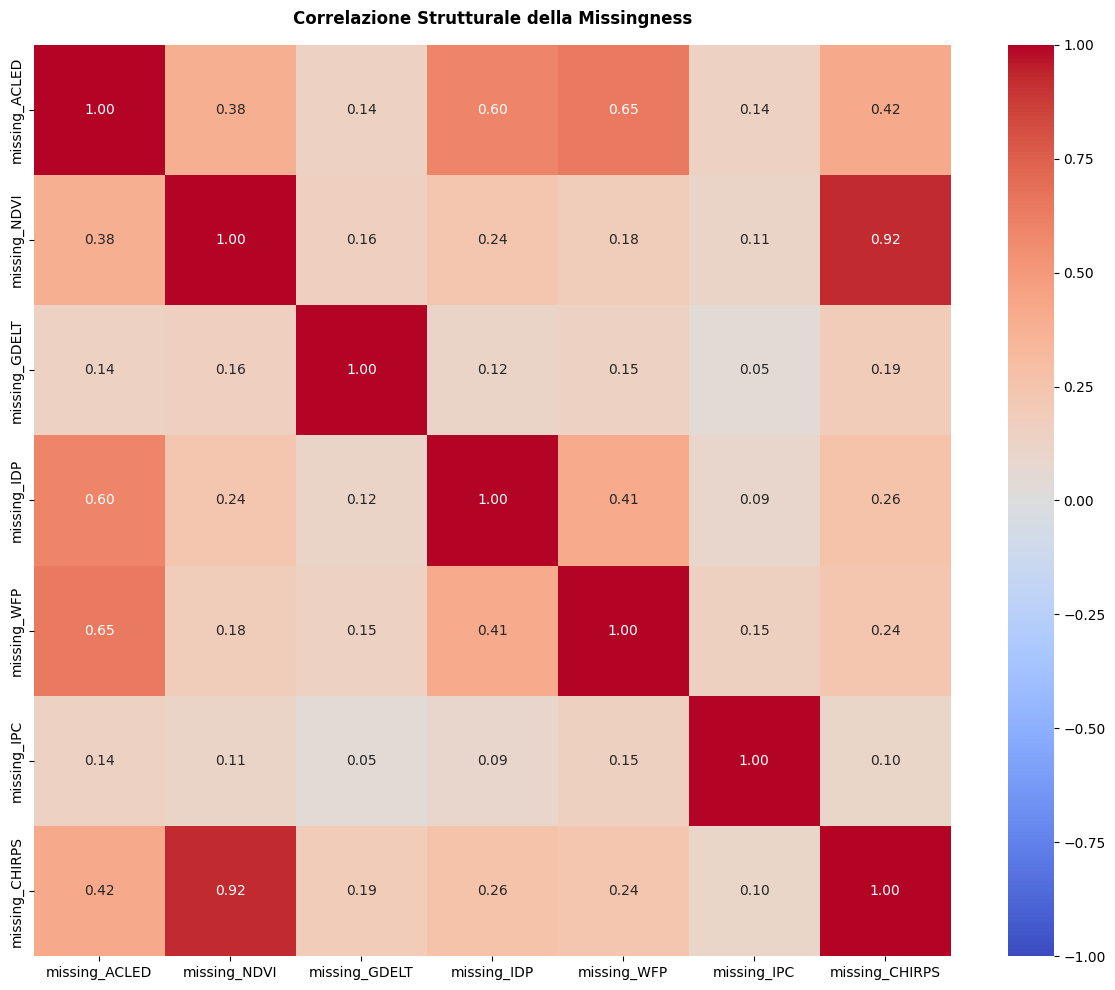

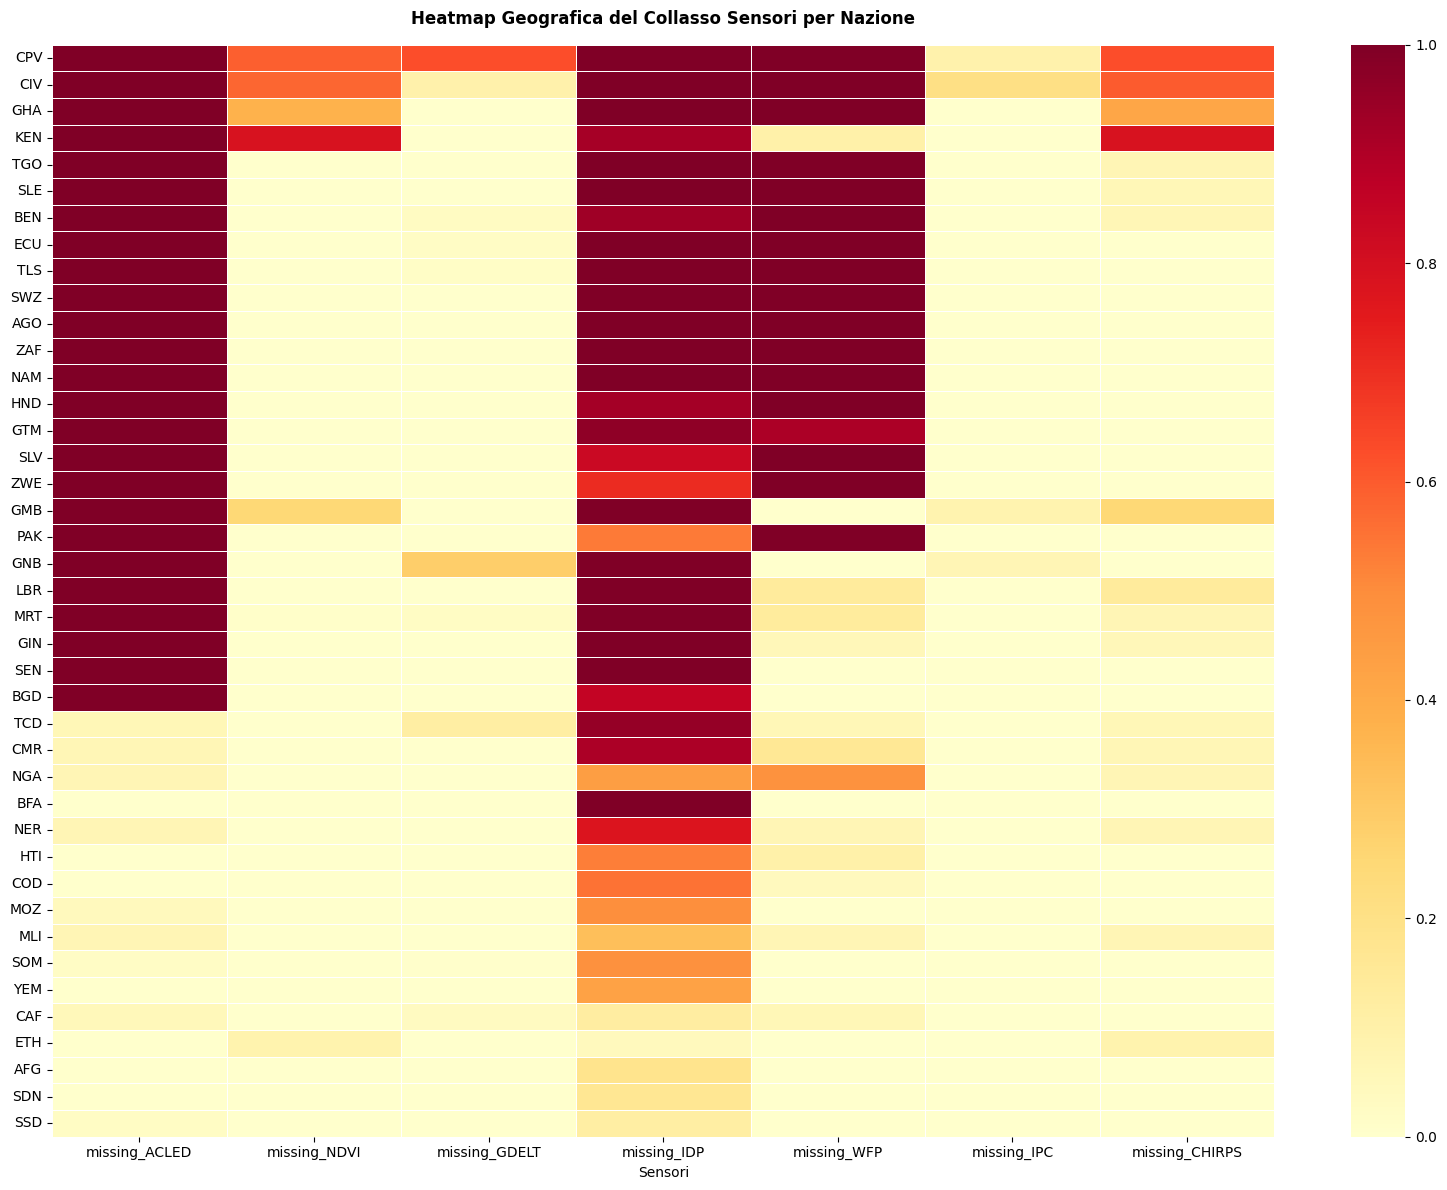

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Assicurazione del formato datetime per l'aggregazione temporale
df['From'] = pd.to_datetime(df['From'])

# 1. Definizione dei sensori target (7 fonti integrate)
target_sensors = {
    'ACLED': 'acled_total_fatalities_per_100k_population',
    'NDVI': 'ndvi_viq',
    'GDELT': 'gdelt_verbal_coop_events_per_100k_population',
    'IDP': 'idp_population_over_adm1_population',
    'WFP': 'wfp_price',
    'IPC': 'phase_3plus_percentage',
    'CHIRPS': 'rain_1m_sum'
}

# 2. Creazione della Shadow Matrix (1 = Dato Mancante, 0 = Dato Presente)
shadow_df = df.copy()
for sensor_name, col_name in target_sensors.items():
    shadow_df[f'missing_{sensor_name}'] = shadow_df[col_name].isna().astype(int)

missing_cols = [f'missing_{name}' for name in target_sensors.keys()]

# ---------------------------------------------------------
# ANALISI 1: Correlazione Strutturale (Tra Dataset)
# ---------------------------------------------------------
missing_corr = shadow_df[missing_cols].corr()

plt.figure(figsize=(12, 10)) # Espansione per matrice 7x7
sns.heatmap(missing_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title("Correlazione Strutturale della Missingness", pad=15, fontweight='bold')
plt.tight_layout()
plt.savefig("ANALISI_NULLI_correlazione_strutturale.png", dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# ANALISI 3: Correlazione Geografica (Blackout per Nazione)
# ---------------------------------------------------------
spatial_missing = shadow_df.groupby('Country')[missing_cols].mean()
spatial_missing['total_failure_score'] = spatial_missing.sum(axis=1)
spatial_missing = spatial_missing.sort_values(by='total_failure_score', ascending=False).drop(columns='total_failure_score')

plt.figure(figsize=(16, 12)) # Espansione per asse X (7 Sensori) e Y (Nazioni)
sns.heatmap(spatial_missing, annot=False, cmap='YlOrRd', vmin=0, vmax=1, linewidths=0.5)
plt.title("Heatmap Geografica del Collasso Sensori per Nazione", pad=15, fontweight='bold')
plt.ylabel("")
plt.xlabel("Sensori")
plt.tight_layout()
plt.savefig("ANALISI_NULLI_correlazione_geografica.png", dpi=300, bbox_inches='tight')
plt.show()

In [16]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import scipy.stats as stats

# Isolamento esclusivo delle feature analitiche di monitoraggio dal dataset originario[cite: 32]
numeric_features = ['acled_total_fatalities_per_100k_population','ndvi_viq','gdelt_verbal_coop_events_per_100k_population','idp_population_over_adm1_population','wfp_price', 'phase_3plus_percentage', 'rain_1m_sum'
]

df_numeric = df[numeric_features].copy() #[cite: 32]

def test_mcar_vs_mar(dataframe, target_col):
    """
    Verifica strutturale se l'assenza del dato in target_col dipende dalle altre feature osservate.
    Un AUC significativamente > 0.5 o p-value univariati < 0.05 indicano che il dato NON è MCAR.
    """
    if dataframe[target_col].isna().sum() == 0:
        return f"Varianza nulla: nessun valore mancante in {target_col}."

    # Creazione variabile dummy per la missingness
    df_test = dataframe.copy()
    df_test['missing_target'] = df_test[target_col].isna().astype(int)

    # Separazione dei predittori (si rimuovono le righe con nulli nei predittori per coerenza del training)
    predictor_cols = [col for col in dataframe.columns if col != target_col]
    df_model = df_test.dropna(subset=predictor_cols)

    X = df_model[predictor_cols]
    y = df_model['missing_target']

    if len(y.unique()) < 2:
        return f"Impossibile addestrare il modello per {target_col}: classe di missingness non bilanciata nei dati puliti."

    # 1. Modello Predittivo Multivariato (Regressione Logistica)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    preds = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, preds)

    print(f"--- Risultati Analisi Missingness: {target_col} ---")
    print(f"ROC AUC Score (Prevedibilità dell'assenza): {auc:.3f}")

    if auc > 0.6:
        print("Conclusione Multivariata: RIFIUTO MCAR. L'assenza del dato è prevedibile dalle altre feature (Probabile MAR/MNAR).")
    else:
        print("Conclusione Multivariata: MCAR NON RIFIUTATO. L'assenza appare stocastica rispetto a questi predittori.")

    # 2. Verifica Statistica Univariata (Welch's T-Test)
    print("T-Test Differenze Medie (Gruppo Missing vs Gruppo Osservato):")
    for col in predictor_cols:
        missing_group = df_test[df_test['missing_target'] == 1][col].dropna()
        observed_group = df_test[df_test['missing_target'] == 0][col].dropna()

        if len(missing_group) > 5 and len(observed_group) > 5:
            stat, p_val = stats.ttest_ind(missing_group, observed_group, equal_var=False)
            if p_val < 0.05:
                print(f" - {col}: Differenza statisticamente significativa (p-value={p_val:.4e}). Il test univariato supporta MAR.")
            else:
                 print(f" - {col}: Differenza NON significativa (p-value={p_val:.4e}).")

# Esecuzione pipeline in batch
for feature in numeric_features:
    test_mcar_vs_mar(df_numeric, feature)
    print("\\n")

--- Risultati Analisi Missingness: acled_total_fatalities_per_100k_population ---
ROC AUC Score (Prevedibilità dell'assenza): 0.615
Conclusione Multivariata: RIFIUTO MCAR. L'assenza del dato è prevedibile dalle altre feature (Probabile MAR/MNAR).
T-Test Differenze Medie (Gruppo Missing vs Gruppo Osservato):
 - ndvi_viq: Differenza statisticamente significativa (p-value=2.8099e-25). Il test univariato supporta MAR.
 - gdelt_verbal_coop_events_per_100k_population: Differenza statisticamente significativa (p-value=2.4014e-24). Il test univariato supporta MAR.
 - idp_population_over_adm1_population: Differenza statisticamente significativa (p-value=3.8209e-13). Il test univariato supporta MAR.
 - wfp_price: Differenza statisticamente significativa (p-value=2.7895e-50). Il test univariato supporta MAR.
 - phase_3plus_percentage: Differenza statisticamente significativa (p-value=0.0000e+00). Il test univariato supporta MAR.
 - rain_1m_sum: Differenza statisticamente significativa (p-value=2.

/opt/anaconda3/envs/nlp_clustering/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/envs/nlp_clustering/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/envs/nlp_clustering/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/envs/nlp_clustering/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/nlp_clustering/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/nlp_clustering/lib/python3.10/site-packages/sklearn/utils/extmath

In [17]:
# Aggiungi questa importazione all'inizio dello script
import ipywidgets as widgets
from IPython.display import display

# ... [codice precedente: setup e matrice strutturale] ...

# ---------------------------------------------------------
# ANALISI 2: Correlazione Temporale (Rendering Interattivo)
# ---------------------------------------------------------
shadow_df['year_month'] = shadow_df['From'].dt.to_period('M')
temporal_trend = shadow_df.groupby('year_month')[missing_cols].mean()

# 1. Definizione della funzione di callback per il plot dinamico
def plot_temporal_trend(sensori_selezionati):
    plt.figure(figsize=(18, 8))

    # Gestione dell'eccezione: nessun sensore selezionato
    if not sensori_selezionati:
        plt.text(0.5, 0.5, "Seleziona almeno un sensore dal menu",
                 ha='center', va='center', fontsize=14, color='gray')
        plt.axis('off')
    else:
        # Generazione vettori dinamica
        for col in sensori_selezionati:
            plt.plot(temporal_trend.index.astype(str), temporal_trend[col],
                     label=col, marker='o', markersize=4)

        plt.title("Evoluzione Temporale del Tasso di Dati Mancanti", pad=15, fontweight='bold')
        plt.ylabel("Tasso di Missingness (0 - 1)")
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.legend()

    plt.tight_layout()
    plt.show()

# 2. Inizializzazione del Widget SelectMultiple
selezione_sensori = widgets.SelectMultiple(
    options=missing_cols,
    value=missing_cols,  # Inizializzazione di default: tutti i sensori attivi
    description='Sensori:',
    disabled=False,
    layout=widgets.Layout(width='40%', height='140px')
)

# 3. Esecuzione del modulo interattivo
widgets.interactive(plot_temporal_trend, sensori_selezionati=selezione_sensori)

interactive(children=(SelectMultiple(description='Sensori:', index=(0, 1, 2, 3, 4, 5, 6), layout=Layout(height…